# Evaluation Metrics — Measuring What Actually Matters

## The Core Question

A model that predicts "no fraud" 100% of the time is 99.9% accurate on a fraud dataset.
It's also completely useless.

Accuracy is a lie whenever classes are imbalanced or errors have asymmetric costs.
This notebook builds the vocabulary you need to actually evaluate a model.

## What We Cover

| Section | Metric | Use Case |
|---|---|---|
| 1 | Accuracy — and why it misleads | Baseline sanity check |
| 2 | Confusion matrix | Understanding error types (Classification diagnostics) |
| 3 | Precision, Recall, F1 | Classification with class imbalance |
| 4 | ROC curve & AUC | Threshold-independent classifier comparison |
| 5 | Regression metrics (RMSE, MAE, RMSLE, R²) | Any regression problem MSE, RMSE, MAE, R² |

## The Rule

> Choose your metric **before** you train. The metric you optimize for is the
> model you get.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, roc_curve, auc, mean_squared_error,
                              mean_absolute_error, r2_score)
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## 1. Why Accuracy Is Misleading

Consider a **fraud detection** model: 99% of transactions are legitimate, 1% are fraud.

A model that predicts "not fraud" for **every single transaction** gets 99% accuracy.  
But it catches **0 frauds** — completely useless.

This is the **accuracy paradox**. It happens whenever classes are imbalanced.

| Scenario | Imbalanced? | Use Instead |
|---|---|---|
| Spam detection | Yes (most is ham) | Precision + Recall |
| Disease screening | Yes (rare disease) | Recall (catch all cases) |
| Fraud detection | Very yes | F1, AUC-ROC |
| Image classification (balanced) | No | Accuracy is fine |

=== Accuracy Paradox: Fraud Detection ===
Dataset: 990 legitimate, 10 fraudulent

Dumb model (predict all 0):
  Accuracy: 99.0%  ← looks great!
  Frauds caught: 0 / 10  ← actually terrible

Decent model:
  Accuracy:      99.5%
  Frauds caught: 8 / 10


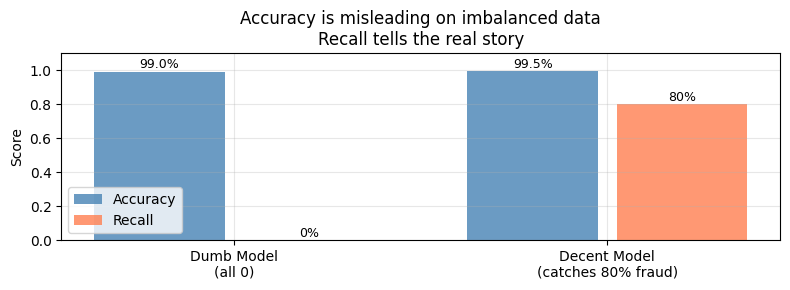

In [2]:
# Imbalanced dataset: 990 negatives, 10 positives (1% fraud)
np.random.seed(42)
y_true = np.array([0]*990 + [1]*10)

# A "dumb" model: always predicts 0
y_dumb = np.zeros_like(y_true)

# A decent model: catches 8 of 10 frauds but has some false alarms
y_decent = np.zeros_like(y_true)
fraud_idx = np.where(y_true == 1)[0]
y_decent[fraud_idx[:8]] = 1    # catches 8 frauds
y_decent[[5, 50, 150]] = 1     # 3 false alarms

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

print("=== Accuracy Paradox: Fraud Detection ===")
print(f"Dataset: {sum(y_true==0)} legitimate, {sum(y_true==1)} fraudulent")
print()
print("Dumb model (predict all 0):")
print(f"  Accuracy: {accuracy(y_true, y_dumb):.1%}  ← looks great!")
print(f"  Frauds caught: 0 / {sum(y_true==1)}  ← actually terrible")
print()
print("Decent model:")
print(f"  Accuracy:      {accuracy(y_true, y_decent):.1%}")
print(f"  Frauds caught: {sum((y_decent==1) & (y_true==1))} / {sum(y_true==1)}")

fig, ax = plt.subplots(figsize=(8, 3))
models = ['Dumb Model\n(all 0)',
          'Decent Model\n(catches 80% fraud)']
accs   = [accuracy(y_true, y_dumb), accuracy(y_true, y_decent)]
recalls= [0, sum((y_decent==1) & (y_true==1))/sum(y_true==1)]
x = np.arange(2)
ax.bar(x-0.2, accs,    0.35, label='Accuracy',  color='steelblue', alpha=0.8)
ax.bar(x+0.2, recalls, 0.35, label='Recall',    color='coral',     alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Accuracy is misleading on imbalanced data\nRecall tells the real story')
ax.legend()
for i, (a, r) in enumerate(zip(accs, recalls)):
    ax.text(i-0.2, a+0.02, f'{a:.1%}', ha='center', fontsize=9)
    ax.text(i+0.2, r+0.02, f'{r:.0%}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 2. Confusion Matrix

The confusion matrix shows **where** your model is making mistakes.

```
                  Predicted
                  Negative  Positive
Actual  Negative  [ TN       FP ]   ← FP = False Alarm
        Positive  [ FN       TP ]   ← FN = Missed case
```

- **TP** (True Positive): Correct positive
- **TN** (True Negative): Correct negative
- **FP** (False Positive): False alarm — said positive, was negative
- **FN** (False Negative): Missed — said negative, was positive

> In medicine: FN (missed cancer) is usually worse than FP (unnecessary test).  
> In spam: FP (real email marked spam) is usually worse than FN (spam gets through).

=== Confusion Matrix ===
                  Predicted
                  NotSpam   Spam
Actual  NotSpam        6      2   (FP = real email → spam folder)
        Spam           2      5   (FN = spam got through)

TP=5  FP=2  TN=6  FN=2


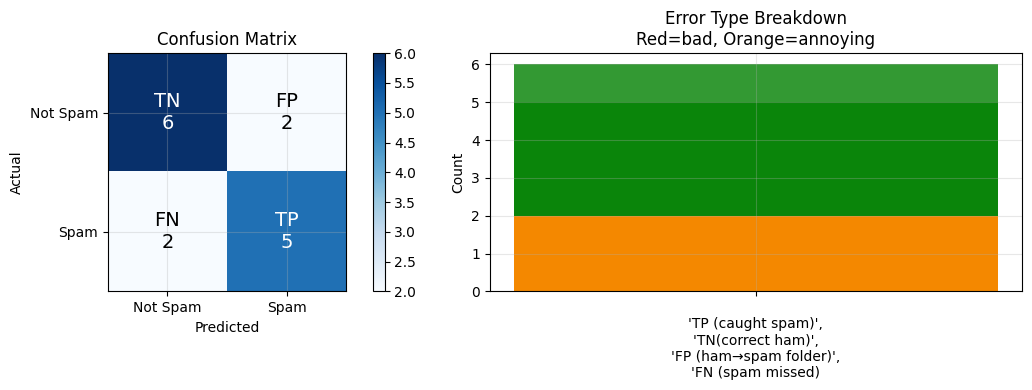

In [3]:
# Realistic spam classifier predictions
y_true = np.array([0,1,0,1,0,0,1,1,0,1,1,0,0,1,0])
y_pred = np.array([0,1,0,0,1,0,1,1,0,1,0,0,1,1,0])

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=== Confusion Matrix ===")
print("                  Predicted")
print("                  NotSpam   Spam")
print(f"Actual  NotSpam   {tn:6d}   {fp:4d}   (FP = real email → spam folder)")
print(f"        Spam      {fn:6d}   {tp:4d}   (FN = spam got through)")
print()
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1])
axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Not Spam', 'Spam'])
axes[0].set_yticklabels(['Not Spam', 'Spam'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        label = ['TN','FP','FN','TP'][i*2+j]
        axes[0].text(j, i, f'{label}\n{cm[i,j]}', ha='center', va='center',
                    fontsize=14, color='white' if cm[i,j] > cm.max()*0.6 else 'black')
plt.colorbar(im, ax=axes[0])

# What errors cost
error_types = ["""
'TP (caught spam)',
'TN(correct ham)',
'FP (ham→spam folder)',
'FN (spam missed)"""]
counts = [tp, tn, fp, fn]
colors = ['green', 'green', 'red', 'orange']
axes[1].bar(error_types, counts, color=colors, alpha=0.8)
axes[1].set_title('Error Type Breakdown\nRed=bad, Orange=annoying')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 3. Precision, Recall & F1

$$\text{Precision} = \frac{TP}{TP+FP} \quad \text{"Of what I said was positive, how many were?"}$$

$$\text{Recall} = \frac{TP}{TP+FN} \quad \text{"Of all actual positives, how many did I find?"}$$

$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

### The Precision-Recall Tradeoff
Adjusting the **classification threshold** trades precision for recall:
- Lower threshold → catch more positives → higher recall, lower precision
- Higher threshold → be more certain → higher precision, lower recall

**Which matters more depends on the problem:**
- Cancer screening: **Recall** (missing a case is fatal)
- Spam filter: **Precision** (wrong positives annoy users)

### Precision: The 'Purity' of Positive Predictions

Measures the accuracy of positive predictions. It answers the question, “Of all the items the model labeled as positive, how many were actually positive?”
<br/><br/>
**Question**: Of all the emails the model flagged as spam, what fraction were *actually* spam?

`Precision = TP / (TP + FP)`

A high precision means the model is trustworthy when it says something is spam (it generates few false positives).

In [4]:
precision = precision_score(y_true, y_pred)
print(f"Precision: {precision:.2f}")

Precision: 0.71


### Recall (Sensitivity): Finding All the Positives

Measures the model’s ability to find all the positive instances. It answers the question, “Of all the actual positives, how many did the model correctly identify?”
<br/><br/>
**Question**: Of all the emails that were *actually* spam, what fraction did the model correctly identify?

`Recall = TP / (TP + FN)`

A high recall means the model is good at finding all the spam emails (it generates few false negatives).

In [5]:
recall = recall_score(y_true, y_pred)
print(f"Recall: {recall:.2f}")

Recall: 0.71


### F1-Score: The Harmonic Mean

The harmonic mean of precision and recall. It balances the two metrics into a single number, making it especially useful when precision and recall are in trade-off.
<br/><br/>
Often, there's a tradeoff between precision and recall. The F1-score provides a single metric that balances both.

`F1 = 2 * (Precision * Recall) / (Precision + Recall)`

It's the harmonic mean of precision and recall, and it gives a better measure of a model's performance than accuracy on imbalanced datasets.

In [6]:
f1 = f1_score(y_true, y_pred)
print(f"F1-Score: {f1:.2f}")

F1-Score: 0.71


=== Precision-Recall at Different Thresholds ===
Best F1=0.843 at threshold=0.52
  Precision=0.805  Recall=0.885


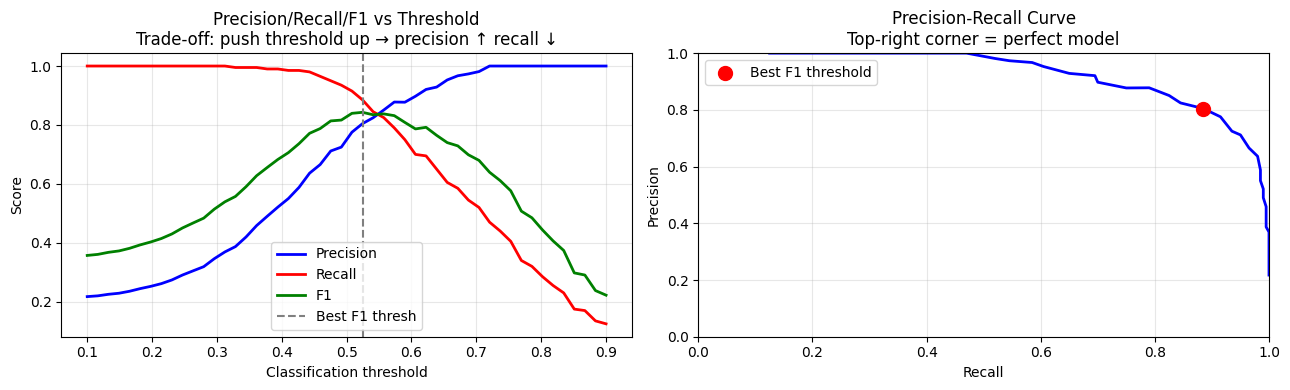

In [7]:
# Precision-recall tradeoff
np.random.seed(0)
n_pos, n_neg = 200, 800
scores_pos = np.random.normal(0.7, 0.15, n_pos)  # true positives
scores_neg = np.random.normal(0.3, 0.15, n_neg)  # true negatives
scores = np.concatenate([scores_pos, scores_neg])
y_true_pr = np.array([1]*n_pos + [0]*n_neg)

thresholds = np.linspace(0.1, 0.9, 50)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred_t = (scores >= thresh).astype(int)
    if y_pred_t.sum() == 0:
        precisions.append(1.0)
        recalls.append(0.0)
        f1s.append(0.0)
        continue
    p = precision_score(y_true_pr, y_pred_t, zero_division=0)
    r = recall_score(y_true_pr, y_pred_t)
    f = f1_score(y_true_pr, y_pred_t)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

best_thresh_idx = np.argmax(f1s)
print("=== Precision-Recall at Different Thresholds ===")
print(f"Best F1={f1s[best_thresh_idx]:.3f} at threshold={thresholds[best_thresh_idx]:.2f}")
print(f"  Precision={precisions[best_thresh_idx]:.3f}  Recall={recalls[best_thresh_idx]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Threshold sweep
axes[0].plot(thresholds, precisions, 'b-', lw=2, label='Precision')
axes[0].plot(thresholds, recalls, 'r-', lw=2, label='Recall')
axes[0].plot(thresholds, f1s, 'g-', lw=2, label='F1')
axes[0].axvline(thresholds[best_thresh_idx], color='gray', linestyle='--', label='Best F1 thresh')
axes[0].set_xlabel('Classification threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision/Recall/F1 vs Threshold\nTrade-off: push threshold up → precision ↑ recall ↓')
axes[0].legend()

# PR curve
axes[1].plot(recalls, precisions, 'b-', lw=2)
axes[1].scatter(recalls[best_thresh_idx], precisions[best_thresh_idx],
                color='red', s=100, zorder=5, label='Best F1 threshold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve\nTop-right corner = perfect model')
axes[1].set_xlim(0,1)
axes[1].set_ylim(0,1)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. ROC Curve & AUC

**ROC (Receiver Operating Characteristic)** plots:
- X-axis: False Positive Rate = FP / (FP + TN)
- Y-axis: True Positive Rate (Recall) = TP / (TP + FN)

At every possible threshold. **AUC (Area Under Curve):**
- AUC = 1.0 → perfect classifier
- AUC = 0.5 → random guessing (diagonal line)
- AUC < 0.5 → worse than random

**Advantage over F1:** AUC is threshold-independent — measures overall discriminating ability.

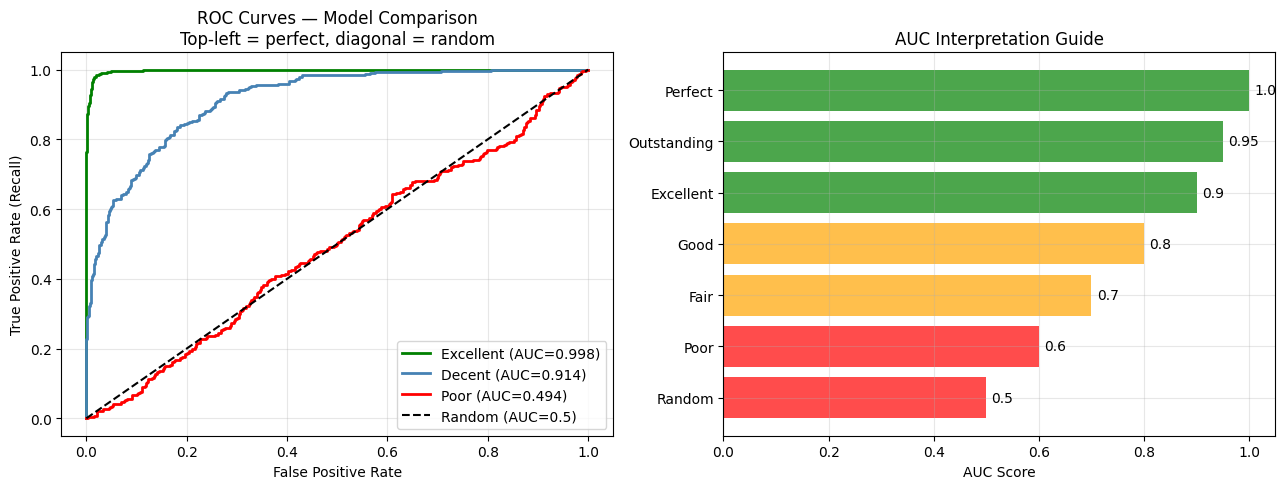

Excellent model AUC: 0.9980
AUC = probability that model ranks a random positive higher than a random negative


In [8]:
# Compare multiple models with ROC curves
np.random.seed(0)
n = 1000
y_true_roc = np.array([1]*300 + [0]*700)

# Simulate model probability scores
scores_excellent = np.where(y_true_roc==1,
    np.random.beta(8,2,n), np.random.beta(2,8,n))
scores_decent    = np.where(y_true_roc==1,
    np.random.beta(4,2,n), np.random.beta(2,4,n))
scores_poor      = np.where(y_true_roc==1,
    np.random.beta(2,2,n), np.random.beta(2,2,n))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for scores, label, color in [
    (scores_excellent, 'Excellent', 'green'),
    (scores_decent,    'Decent',    'steelblue'),
    (scores_poor,      'Poor',      'red'),
]:
    fpr, tpr, _ = roc_curve(y_true_roc, scores)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC={roc_auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', lw=1.5, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves — Model Comparison\nTop-left = perfect, diagonal = random')
axes[0].legend()

# AUC interpretation guide
auc_vals   = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
auc_labels = ['Random', 'Poor', 'Fair', 'Good', 'Excellent', 'Outstanding', 'Perfect']
colors_bar = ['red','red','orange','orange','green','green','green']
axes[1].barh(auc_labels, auc_vals, color=colors_bar, alpha=0.7)
axes[1].set_xlabel('AUC Score')
axes[1].set_title('AUC Interpretation Guide')
axes[1].set_xlim(0, 1.05)
for i, v in enumerate(auc_vals):
    axes[1].text(v+0.01, i, f'{v}', va='center')

plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_true_roc, scores_excellent)
print(f"Excellent model AUC: {auc(fpr, tpr):.4f}")
print("AUC = probability that model ranks a random positive higher than a random negative")

---
## 5. Regression Metrics

For regression (predicting a continuous value):

| Metric | Formula | Sensitive to outliers? | Interpretable? |
|---|---|---|---|
| **MSE** | `mean((y-ŷ)²)` | Yes (squares errors) | Units² |
| **RMSE** | `√MSE` | Yes | Same units as y |
| **MAE** | `mean(|y-ŷ|)` | No | Same units as y |
| **R²** | `1 - SS_res/SS_tot` | Somewhat | 0–1 scale |
| **MAPE** | `mean(|y-ŷ|/y) × 100` | No | % error |

**R² (coefficient of determination):** How much variance in y does the model explain?  
- R²=1.0: perfect predictions
- R²=0.0: model is no better than predicting the mean
- R²<0.0: model is worse than the mean

=== Regression Metrics Comparison ===
Model A (consistent):
  MSE:     22.65  ← large because it squares errors
  RMSE:     4.76  ← in same units as y (most common)
  MAE:      3.78  ← robust to outliers
  R²:     0.9457  ← 94.6% of variance explained
  MAPE:    3.89%

Model B (outlier errors):
  MSE:    101.45  ← large because it squares errors
  RMSE:    10.07  ← in same units as y (most common)
  MAE:      4.09  ← robust to outliers
  R²:     0.7569  ← 75.7% of variance explained
  MAPE:    4.35%


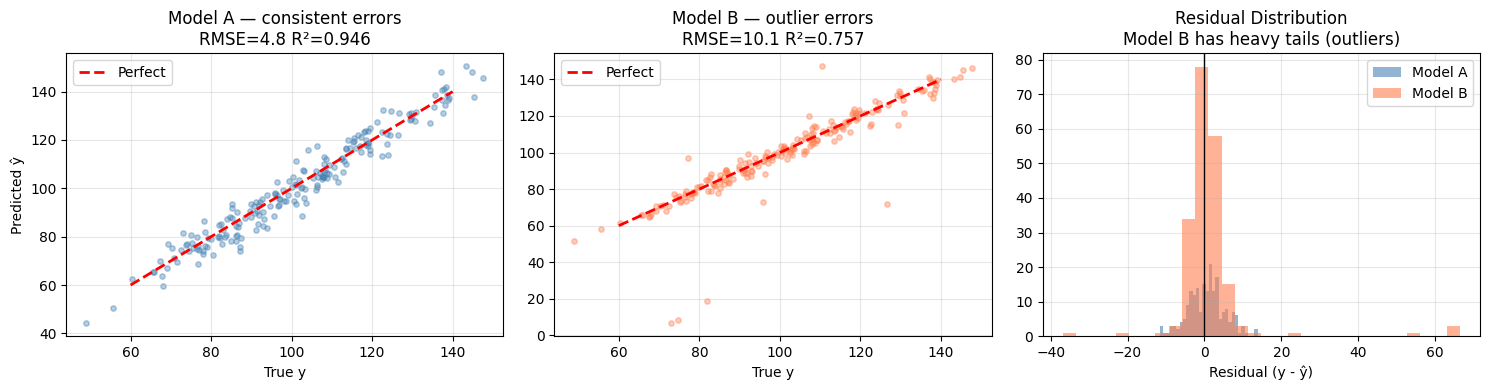

In [9]:
# Compare regression metrics on different error profiles
np.random.seed(0)
n = 200
y_true_reg = np.random.normal(100, 20, n)

# Model A: consistent small errors
y_pred_A = y_true_reg + np.random.normal(0, 5, n)
# Model B: usually good but some large outlier errors
errors_B = np.random.normal(0, 3, n)
errors_B[np.random.choice(n, 10)] += np.random.normal(0, 40, 10)  # outliers
y_pred_B = y_true_reg + errors_B

def regression_metrics(y_true, y_pred, name):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    print(f"{name}:")
    print(f"  MSE:  {mse:8.2f}  ← large because it squares errors")
    print(f"  RMSE: {rmse:8.2f}  ← in same units as y (most common)")
    print(f"  MAE:  {mae:8.2f}  ← robust to outliers")
    print(f"  R²:   {r2:8.4f}  ← {r2*100:.1f}% of variance explained")
    print(f"  MAPE: {mape:7.2f}%")
    return rmse, mae, r2

print("=== Regression Metrics Comparison ===")
rmse_a, mae_a, r2_a = regression_metrics(y_true_reg, y_pred_A, "Model A (consistent)")
print()
rmse_b, mae_b, r2_b = regression_metrics(y_true_reg, y_pred_B, "Model B (outlier errors)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_true_reg, y_pred_A, alpha=0.4, s=15, color='steelblue')
axes[0].plot([60,140],[60,140],'r--', lw=2, label='Perfect')
axes[0].set_title(f'Model A — consistent errors\nRMSE={rmse_a:.1f} R²={r2_a:.3f}')
axes[0].set_xlabel('True y')
axes[0].set_ylabel('Predicted ŷ')
axes[0].legend()

axes[1].scatter(y_true_reg, y_pred_B, alpha=0.4, s=15, color='coral')
axes[1].plot([60,140],[60,140],'r--', lw=2, label='Perfect')
axes[1].set_title(f'Model B — outlier errors\nRMSE={rmse_b:.1f} R²={r2_b:.3f}')
axes[1].set_xlabel('True y')
axes[1].legend()

residuals_a = y_true_reg - y_pred_A
residuals_b = y_true_reg - y_pred_B
axes[2].hist(residuals_a, bins=30, alpha=0.6, color='steelblue', label='Model A')
axes[2].hist(residuals_b, bins=30, alpha=0.6, color='coral', label='Model B')
axes[2].axvline(0, color='k', lw=1)
axes[2].set_title('Residual Distribution\nModel B has heavy tails (outliers)')
axes[2].set_xlabel('Residual (y - ŷ)')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Summary — Evaluation Metrics

### Classification Metrics Cheat Sheet

```python
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve,
)

# The one-liner report
print(classification_report(y_true, y_pred))

# Threshold-independent
roc_auc_score(y_true, y_prob)         # AUC-ROC
average_precision_score(y_true, y_prob) # AUC-PR (better for imbalance)
```

### Regression Metrics Cheat Sheet

```python
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
mae   = mean_absolute_error(y_true, y_pred)
rmsle = np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))
r2    = r2_score(y_true, y_pred)
```

### Decision Guide

| Situation | Use |
|---|---|
| Balanced classes | Accuracy, F1 macro |
| Imbalanced, FP costly (spam filter) | Precision |
| Imbalanced, FN costly (cancer screening) | Recall |
| Both matter, imbalanced | F1 / AUC-PR |
| Ranking models, any threshold | AUC-ROC |
| Price/continuous prediction | RMSE + R² |
| Price with outliers | MAE (robust) |
| Kaggle House Prices | RMSLE |

### Next: `cross_validation.ipynb`
Getting a reliable estimate of these metrics — not just one lucky train/test split.
